# CFS 30-Day Mean Sea Level Pressure

In this example, we will:

1) Use WxData to download 30 days of CFS Mean Sea Level Pressure.
2) Calculate the 30-Day Mean for Mean Sea Level Pressure.
3) Make a polar stereographic plot

## Imports

In [1]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import numpy as np


from wxdata import(
    cfs_pressure,
    cyclic_point
)
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
from scipy import signal as signal
from datetime import timedelta

### `cfs_pressure()` Client

***def cfs_pressure(western_bound=-180, 
            eastern_bound=180, 
            northern_bound=90, 
            southern_bound=-90, 
            final_forecast_hour=720,
            proxies=None, 
            clear_recycle_bin=False,
            clear_data=False,
            chunk_size=8192,
            notifications='off',
            path=f"CFS/PRESSURE",
            process_data=True,
            convert_temperature=True,
            convert_to='celsius',
            variables=['best lifted index',
                        '5 wave geopotential height anomaly',
                        '5 wave geopotential height',
                        'absolute vorticity',
                        'convective precipitation',
                        'total precipitation',
                        'convective available potential energy',
                        'categorical freezing rain',
                        'categorical ice pellets',
                        'convective inhibition',
                        'cloud mixing ratio',
                        'categorical rain',
                        'categorical snow',
                        'cloud water',
                        'dew point',
                        'geopotential height anomaly',
                        'geopotential height',
                        'storm relative helicity',
                        'surface lifted index',
                        'large scale non-convective precipitation',
                        'ozone mixing ratio',
                        'parcel lifted index (to 500mb)',
                        'potential temperature',
                        'pressure',
                        'mean sea level pressure',
                        'precipitable water',
                        'relative humidity',
                        'specific humidity',
                        'stream function',
                        'temperature',
                        'total ozone',
                        'u-component of wind',
                        'u-component of storm motion',
                        'v-component of wind',
                        'velocity potential',
                        'v-component of storm motion',
                        'vertical velocity (pressure)',
                        'vertical speed shear']):***

    This function is an end-to-end client that downloads, pre-processes, post-processes CFS Pressure data.
    Post-processing remaps the variable keys from the coded GRIB format into a decoded Plain-Language Format
    
    Required Arguments: None.
    
    Optional Arguments:
    
    1) western_bound (Float or Integer) - Default=-180. The western bound of the data needed. 

    2) eastern_bound (Float or Integer) - Default=180. The eastern bound of the data needed.

    3) northern_bound (Float or Integer) - Default=90. The northern bound of the data needed.

    4) southern_bound (Float or Integer) - Default=-90. The southern bound of the data needed.

    5) final_forecast_hour (Integer) - Default=720 (30-Days). The last forecast timestep the user wishes to download.
        The CFS outputs 6 hourly data for the span of several months. Note that if the user wishes to download
        6 hourly data for several months, processing times may be long. Must be a multiple of 6. 

    6) proxies (dict or None) - If the user is using proxy server(s), the user must change the following:

       proxies=None ---> proxies={
                               'http':'http://your-proxy-address:port',
                               'https':'http://your-proxy-address:port'
                               }
                               
        
    7) clear_recycle_bin (Boolean) - Default=False. When set to True, the contents in your recycle/trash bin will be 
        deleted with each run of the program you are calling WxData. This setting is to help preserve memory on the machine. 
        
    8) clear_data (Boolean) - Default=False. When set to False, the scanner safe-guard remains in place (recommended for most users).
        When set to True, the scanner safe-guard is disabled and directory branch is cleared and new data is downloaded. 
        
    9) chunk_size (Integer) - Default=8192. The size of the chunks when writing the GRIB/NETCDF data to a file.
    
    10) notifications (String) - Default='off'. Notification when a file is downloaded and saved to {path}
    
    11) path (String) - Default="CFS/PRESSURE". The path of the local directory where the files will be stored.
    
    12) process_data (Boolean) - Default=True. When set to True, WxData will preprocess the model data. If the user wishes to process the 
       data via their own external method, set process_data=False which means the data will be downloaded but not processed. 
       
    13) convert_temperature (Boolean) - Default=True. When set to True, the temperature related fields will be converted from Kelvin to
        either Celsius or Fahrenheit. When False, this data remains in Kelvin.
        
    14) convert_to (String) - Default='celsius'. When set to 'celsius' temperature related fields convert to Celsius.
        Set convert_to='fahrenheit' for Fahrenheit. 
                                
    15) variables (List) - A list of variable names the user wants to download in plain language. 
    
        Variable Name List for CFS Pressure
        -----------------------------------
        
            'best lifted index'
            '5 wave geopotential height anomaly'
            '5 wave geopotential height'
            'absolute vorticity'
            'convective precipitation'
            'total precipitation'
            'convective available potential energy'
            'categorical freezing rain'
            'categorical ice pellets'
            'convective inhibition'
            'cloud mixing ratio'
            'categorical rain'
            'categorical snow'
            'cloud water'
            'dew point'
            'geopotential height anomaly'
            'geopotential height'
            'storm relative helicity'
            'surface lifted index'
            'large scale non-convective precipitation'
            'ozone mixing ratio'
            'parcel lifted index (to 500mb)'
            'potential temperature'
            'pressure'
            'mean sea level pressure'
            'precipitable water'
            'relative humidity'
            'specific humidity'
            'stream function'
            'temperature'
            'total ozone'
            'u-component of wind'
            'u-component of storm motion'
            'v-component of wind'
            'velocity potential'
            'v-component of storm motion'
            'vertical velocity (pressure)'
            'vertical speed shear'
            
    Returns
    -------
    
    A post-processes xarray.array where the GRIB variable keys are decoded into a plain-language format.
    
    CFS Pressure Data Variables In Plain-Language Format
    ----------------------------------------------------
    
            'mslp'
            'geopotential_height'
            'air_temperature'
            'relative_humidity'
            'specific_humidity'
            'vertical_velocity'
            'u_wind_component'
            'v_wind_component'
            'absolute_vorticity'
            'ozone_mixing_ratio'
            'stream_function'
            'velocity_potential'
            '5_wave_geopotential_height'
            'geopotential_height_anomaly'
            '5_wave_geopotential_height_anomaly'
            '2m_dew_point'
            '2m_relative_humidity'
            'total_precipitation'
            'total_convective_precipitation'
            'total_non_convective_precipitation'
            'categorical_snow'
            'categorical_ice_pellets'
            'categorical_freezing_rain'
            'categorical_rain'
            'surface_lifted_index'
            'best_4_layer_lifted_index'
            'surface_cape'
            'surface_cin'
            'cloud_water'
            'entire_atmosphere_relative_humidity'
            'total_ozone'
            'storm_relative_helicity'
            'u_component_of_storm_motion'
            'v_component_of_storm_motion'
            'tropopause_pressure'
            'tropopause_height'
            'tropopause_u_wind_component'
            'tropopause_v_wind_component'
            'tropopause_temperature'
            'tropopause_vertical_speed_shear'
            'max_wind_u_component'
            'max_wind_v_component'
            'max_wind_geopotential_height'
            'max_wind_pressure'
            'max_wind_temperature'
            'temperature_height_above_sea'
            'u_wind_component_height_above_sea'
            'v_wind_component_height_above_sea'
            'zero_deg_c_isotherm_geopotential_height'
            'zero_deg_c_isotherm_relative_humidity'
            'highest_tropospheric_freezing_level_geopotential_height'
            'highest_tropospheric_freezing_level_relative_humidity'
            'mixed_layer_temperature'
            'mixed_layer_relative_humidity'
            'mixed_layer_specific_humidity'
            'mixed_layer_u_wind_component'
            'mixed_layer_v_wind_component'
            'mixed_layer_dew_point'
            'mixed_layer_precipitable_water'
            'parcel_lifted_index'
            'mixed_layer_cape'
            'mixed_layer_cin'
            'sigma_layer_relative_humidity'
            '995_sigma_temperature'
            '995_sigma_theta'
            '995_sigma_relative_humdity'
            '995_u_wind_component'
            '995_v_wind_component'
            '995_vertical_velocity'
            'potential_vorticity_level_u_wind_component'
            'potential_vorticity_level_v_wind_component'
            'potential_vorticity_level_temperature'
            'potential_vorticity_level_geopotential_height'
            'potential_vorticity_level_air_pressure'
            'potential_vorticity_level_vertical_speed_shear'        

In [2]:
ds = cfs_pressure(southern_bound=30,
                  variables=['mean sea level pressure'])

                                                                                                                       <?, ?B/s]

CFS Pressure Data Processing...
CFS Pressure Data Processing Complete.


In [3]:
ds

<xarray.Dataset> Size: 11MB
Dimensions:     (step: 121, latitude: 61, longitude: 360)
Coordinates:
  * step        (step) float64 968B 0.0 6.0 12.0 18.0 ... 708.0 714.0 720.0
  * latitude    (latitude) float64 488B 30.0 31.0 32.0 33.0 ... 88.0 89.0 90.0
  * longitude   (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
    time        datetime64[ns] 8B ...
    meanSea     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Data variables:
    mslp        (step, latitude, longitude) float32 11MB dask.array<chunksize=(1, 61, 360), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-18T09:06 GRIB to CDM+CF via cfgrib-0.9.1...

### Find the 30-Day Time Mean

In [4]:
mean = ds.mean(dim='step')

In [5]:
mean

<xarray.Dataset> Size: 91kB
Dimensions:     (latitude: 61, longitude: 360)
Coordinates:
  * latitude    (latitude) float64 488B 30.0 31.0 32.0 33.0 ... 88.0 89.0 90.0
  * longitude   (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
    time        datetime64[ns] 8B ...
    meanSea     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Data variables:
    mslp        (latitude, longitude) float32 88kB dask.array<chunksize=(61, 360), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-18T09:06 GRIB to CDM+CF via cfgrib-0.9.1...

### Use `cyclic_point()` To Resolve 180-Degree Meridian Gap

In [6]:
mslp, longitude = cyclic_point(mean,
                               'mslp')

### Create Our 30-Day Time Mean Plot

<a list of 27 text.Text objects>

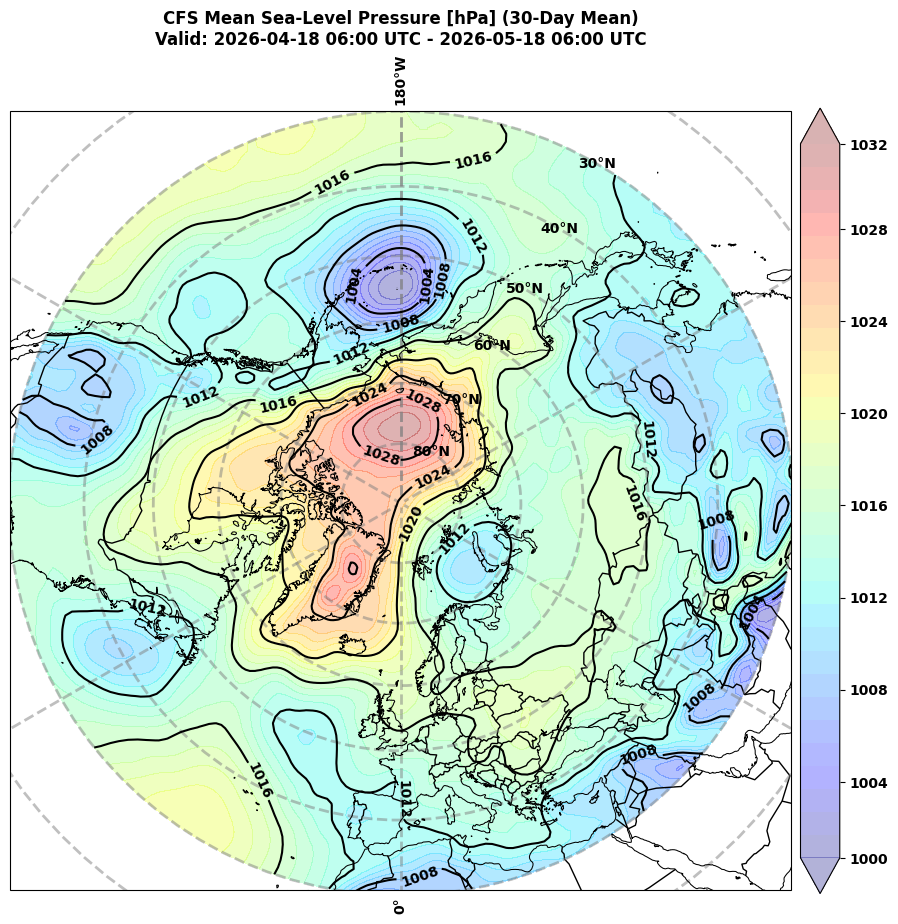

In [7]:
# Global setting for all text to be bold
plt.rcParams['font.weight'] = 'bold'

# Create our figure object
fig = plt.figure(figsize=(12,12))

# Create out axis and map coordinates reference system
ax = fig.add_subplot(1,1,1, projection=ccrs.NorthPolarStereo())

# Set our bounds and data coordinate reference system
ax.set_extent([-180, 180, 30, 90], ccrs.PlateCarree())

# Add coastlines for the outline of the coasts
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.75, zorder=9)

# Add our country borders
ax.add_feature(cfeature.BORDERS, linestyle='-', zorder=2)

init_time = pd.to_datetime(mean['time'].values)
final_time = init_time + timedelta(days=30)

# Create Our Title
ax.set_title(f"CFS Mean Sea-Level Pressure [hPa] (30-Day Mean)\nValid: {init_time.strftime('%Y-%m-%d %H:00 UTC')} - {final_time.strftime('%Y-%m-%d %H:00 UTC')}", 
             fontweight='bold',
             fontsize=12)

# Plot our gridlines
gl = ax.gridlines(draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False # Disable top labels
gl.ylabels_right = False # Disable right labels
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Create our increments for our filled and line contours
contour_levels = np.arange((np.nanmin(mean['mslp'])/100), ((np.nanmax(mean['mslp'])/100) + 4), 4)
filled_levels = np.arange((np.nanmin(mean['mslp'])/100), ((np.nanmax(mean['mslp'])/100) + 1), 1)
colorbar_ticks = np.arange(int(np.nanmin(mean['mslp'])/100), int((np.nanmax(mean['mslp'])/100) + 4), 4)

# Plot our contour data
c = ax.contour(longitude, 
            mean['latitude'], 
            mslp[:, :]/100, 
            transform=ccrs.PlateCarree(),
            zorder=2,
            colors='black',
            levels=contour_levels,
            alpha=1)

# Plot our filled contour data
cs = ax.contourf(longitude, 
            mean['latitude'], 
            mslp[:, :]/100, 
            cmap='jet', 
            transform=ccrs.PlateCarree(),
            levels=filled_levels,
            alpha=0.3,
            extend='both')

# Create our colorbar
fig.colorbar(cs, shrink=0.85, pad=0.01, ticks=colorbar_ticks)

# Label our contours
ax.clabel(c, inline=True, fontsize=10, fmt=lambda x: f"{int(x)}")